# ACGNN Demo

This notebook provides a pipeline for learning GNN-derived gene embeddings on PPI networks.

In [1]:
import os
import copy
import time
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn import metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score

import dgl
from dgl.dataloading import GraphDataLoader

import dataset, model
from train import FocalLoss
from train import (
    calculate_cluster_labels,
    visualize_embeddings_tsne,
    visualize_embeddings_pca,
    create_heatmap_with_stid,
    plot_cosine_similarity_matrix_for_clusters_with_values,
    draw_loss_plot,
    draw_f1_plot,
    draw_max_f1_plot
)


In [2]:
hyperparams = {
    "num_epochs": 5,
    "in_feats": 20,
    "out_feats": 300,
    "num_layers": 2,
    "num_heads": 2,
    "lr": 1e-3,
    "batch_size": 1,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

data_path = "data/emb"
plot = True


In [3]:
num_epochs = hyperparams["num_epochs"]
in_feats = hyperparams["in_feats"]
out_feats = hyperparams["out_feats"]
num_layers = hyperparams["num_layers"]
num_heads = hyperparams["num_heads"]
learning_rate = hyperparams["lr"]
batch_size = hyperparams["batch_size"]
device = hyperparams["device"]

model_dir = os.path.join(data_path, "models")
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(
    model_dir, f"model_dim{out_feats}_lay{num_layers}_epo{num_epochs}.pth"
)

ds = dataset.Dataset(data_path)
dl_train = GraphDataLoader([ds[0]], batch_size=batch_size, shuffle=True)
dl_valid = GraphDataLoader([ds[1]], batch_size=batch_size, shuffle=False)


In [4]:
net = model.TAGCNModel(
    dim_latent=out_feats,
    num_layers=num_layers,
    do_train=True
).to(device)

best_model = model.TAGCNModel(
    dim_latent=out_feats,
    num_layers=num_layers,
    do_train=True
)

optimizer = optim.Adam(net.parameters(), lr=learning_rate)

criterion = FocalLoss(alpha=0.25, gamma=2.0, reduction="mean")
weight = torch.tensor([0.00001, 0.99999]).to(device)


In [5]:
results_path = "results/multiomics_meth/node_embeddings/"
os.makedirs(results_path, exist_ok=True)

all_embeddings_initial, cluster_labels_initial = calculate_cluster_labels(
    best_model, dl_train, device
)
all_embeddings_initial = all_embeddings_initial.reshape(
    all_embeddings_initial.shape[0], -1
)


In [6]:
for graph, _ in dl_train:
    node_emb = best_model.get_node_embeddings(graph).detach().cpu().numpy()

    nx_graph = pickle.load(open(os.path.join(data_path, "raw/emb_train.pkl"), "rb"))
    node_to_index = {n: i for i, n in enumerate(nx_graph.nodes)}

    stid_embeddings = {
        nx_graph.nodes[n]["stId"]: node_emb[node_to_index[n]]
        for n in nx_graph.nodes if "stId" in nx_graph.nodes[n]
    }

    pd.DataFrame.from_dict(stid_embeddings, orient="index").to_csv(
        f"data/multiomics_meth/ppi_embeddings_lr{learning_rate}_dim{out_feats}_initial.csv",
        index_label="stId"
    )

    break


In [7]:
loss_per_epoch_train, loss_per_epoch_valid = [], []
f1_per_epoch_train, f1_per_epoch_valid = [], []
max_f1_scores_train, max_f1_scores_valid = [], []

best_valid_loss = float("inf")

with tqdm(total=num_epochs, desc="Training", unit="epoch") as pbar:
    for epoch in range(num_epochs):
        net.train()
        losses, f1s = [], []

        for graph, _ in dl_train:
            logits = net(graph)
            labels = graph.ndata["significance"].unsqueeze(-1)

            loss = criterion(logits, labels)
            preds = (logits.sigmoid() > 0.5).int()
            f1 = metrics.f1_score(labels.squeeze(1).int(), preds)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            f1s.append(f1)

        loss_per_epoch_train.append(np.mean(losses))
        f1_per_epoch_train.append(np.mean(f1s))

        pbar.update(1)


Training: 100%|██████████| 5/5 [00:05<00:00,  1.19s/epoch]


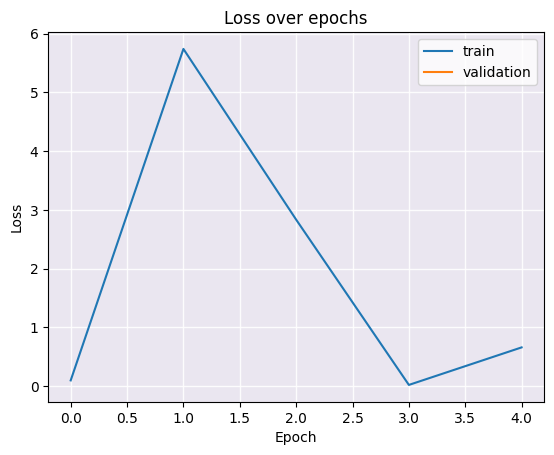

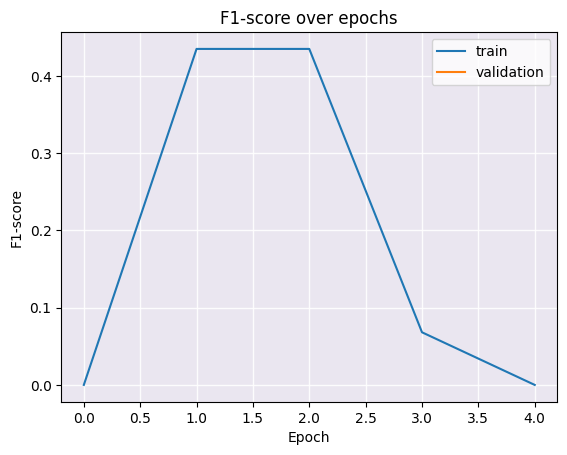

In [8]:
draw_loss_plot(
    loss_per_epoch_train,
    loss_per_epoch_valid,
    os.path.join(results_path, "loss.png")
)

draw_f1_plot(
    f1_per_epoch_train,
    f1_per_epoch_valid,
    os.path.join(results_path, "f1.png")
)


In [ ]:
def plot_embedding_with_cluster_legend(
    embeddings_2d,
    cluster_labels,
    cluster_to_stid,
    title,
    xlabel,
    ylabel,
    save_path,
    cmap=plt.cm.tab20
):
    """
    Plot 2D embeddings with ONE legend entry per cluster,
    labeled by first_node_stId_in_cluster.
    """
    plt.figure(figsize=(9, 7))

    unique_clusters = np.unique(cluster_labels)
    colors = cmap(np.linspace(0, 1, len(unique_clusters)))

    for color, cluster_id in zip(colors, unique_clusters):
        idx = np.where(cluster_labels == cluster_id)[0]

        plt.scatter(
            embeddings_2d[idx, 0],
            embeddings_2d[idx, 1],
            s=12,
            color=color,
            alpha=0.85,
            label=cluster_to_stid.get(cluster_id, f"Cluster {cluster_id}")
        )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    plt.legend(
        title="Label",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True,
        fontsize=18
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


In [29]:
def plot_embedding_with_cluster_legend(
    embeddings_2d,
    cluster_labels,
    cluster_to_stid,
    title,
    xlabel,
    ylabel,
    save_path,
    cmap=plt.cm.tab20
):
    plt.figure(figsize=(10, 8))

    unique_clusters = np.unique(cluster_labels)
    colors = cmap(np.linspace(0, 1, len(unique_clusters)))

    for color, cluster_id in zip(colors, unique_clusters):
        idx = np.where(cluster_labels == cluster_id)[0]

        plt.scatter(
            embeddings_2d[idx, 0],
            embeddings_2d[idx, 1],
            s=12,                 # slightly larger points
            color=color,
            alpha=0.85,
            label=cluster_to_stid.get(cluster_id, f"Cluster {cluster_id}")
        )

    # ---- Styling ----
    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel(ylabel, fontsize=16)
    plt.title(title, fontsize=18)

    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)

    plt.legend(
        title="Label",
        title_fontsize=14,
        fontsize=12,
        markerscale=2.2,      # ⬅️ larger legend dots
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    # plt.legend(
    #     title="Label",
    #     title_fontsize=14,
    #     fontsize=12,
    #     bbox_to_anchor=(1.02, 1),
    #     loc="upper left",
    #     frameon=False    # clean legend
    # )

    # ❌ Remove grid explicitly
    plt.grid(False)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


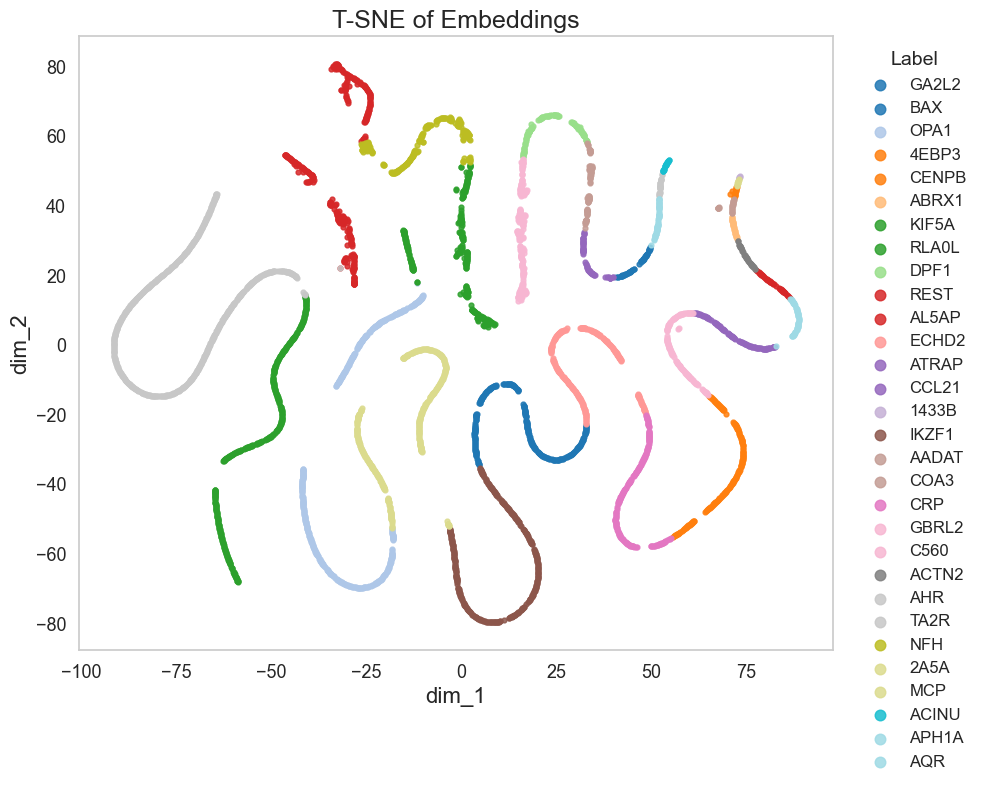

In [31]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=20,
    n_iter=1000,
    random_state=42,
    init="pca"
)

embeddings_tsne = tsne.fit_transform(all_embeddings_initial)

plot_embedding_with_cluster_legend(
    embeddings_2d=embeddings_tsne,
    cluster_labels=cluster_labels_initial,
    cluster_to_stid=first_node_stId_in_cluster_initial,
    title="T-SNE of Embeddings",
    xlabel="dim_1",
    ylabel="dim_2",
    save_path=save_path_t_SNE_initial
)

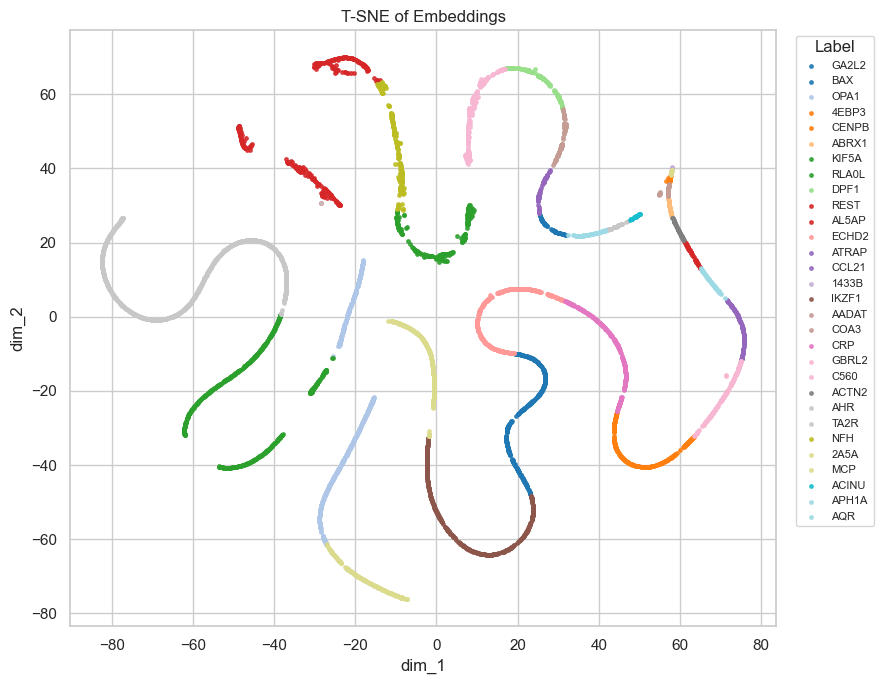

In [24]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=42,
    init="pca"
)

embeddings_tsne = tsne.fit_transform(all_embeddings_initial)

plot_embedding_with_cluster_legend(
    embeddings_2d=embeddings_tsne,
    cluster_labels=cluster_labels_initial,
    cluster_to_stid=first_node_stId_in_cluster_initial,
    title="T-SNE of Embeddings",
    xlabel="dim_1",
    ylabel="dim_2",
    save_path=save_path_t_SNE_initial
)


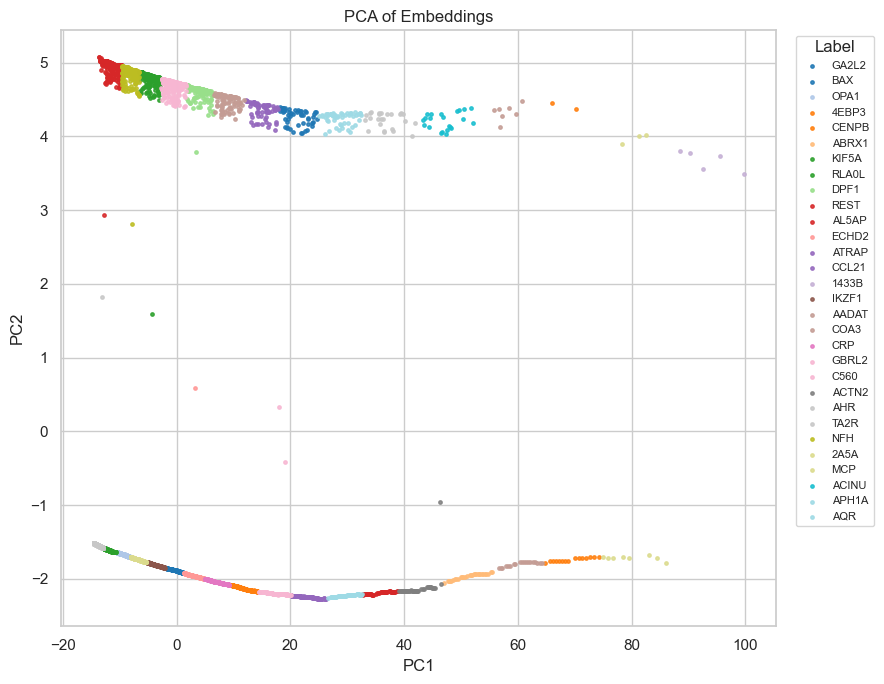

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(all_embeddings_initial)

plot_embedding_with_cluster_legend(
    embeddings_2d=embeddings_pca,
    cluster_labels=cluster_labels_initial,
    cluster_to_stid=first_node_stId_in_cluster_initial,
    title="PCA of Embeddings",
    xlabel="PC1",
    ylabel="PC2",
    save_path=save_path_pca_initial
)


/Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


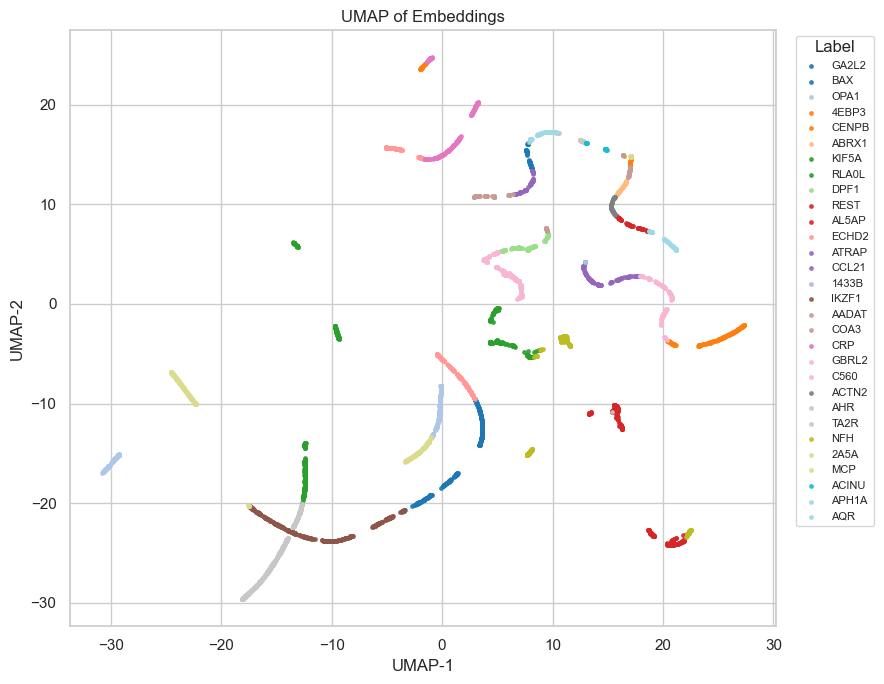

In [26]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embeddings_umap = umap_model.fit_transform(all_embeddings_initial)

plot_embedding_with_cluster_legend(
    embeddings_2d=embeddings_umap,
    cluster_labels=cluster_labels_initial,
    cluster_to_stid=first_node_stId_in_cluster_initial,
    title="UMAP of Embeddings",
    xlabel="UMAP-1",
    ylabel="UMAP-2",
    save_path=os.path.join(results_path, "ppi_embeddings_umap_initial.png")
)


In [19]:
def annotate_cluster_centroids(embeddings_2d, cluster_labels, cluster_to_stid):
    """
    Annotate each cluster using the centroid of its points.

    embeddings_2d : np.ndarray (N, 2)
    cluster_labels : np.ndarray (N,)
    cluster_to_stid : dict {cluster_id: stId}
    """
    for cluster_id, stid in cluster_to_stid.items():
        idx = np.where(cluster_labels == cluster_id)[0]
        if len(idx) == 0:
            continue

        centroid = embeddings_2d[idx].mean(axis=0)

        plt.text(
            centroid[0],
            centroid[1],
            stid,
            fontsize=8,
            weight="bold",
            ha="center",
            va="center",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )



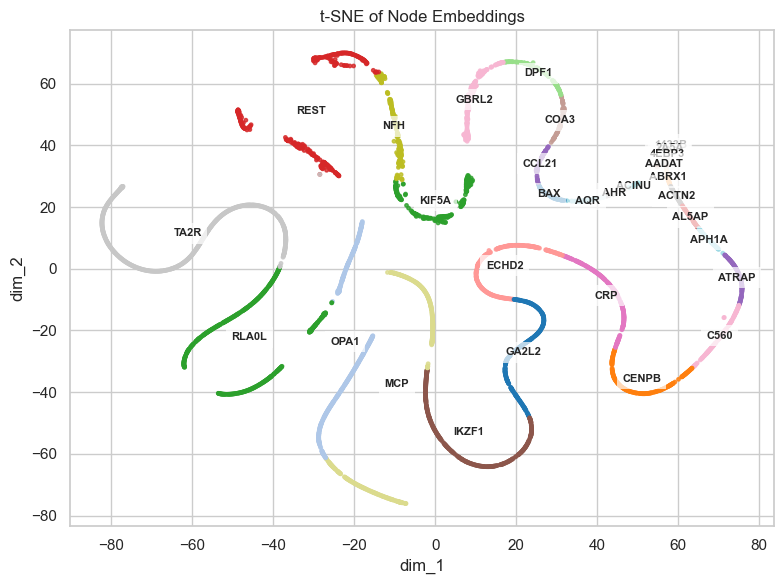

In [20]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=42,
    init="pca"
)

embeddings_tsne = tsne.fit_transform(all_embeddings_initial)

plt.figure(figsize=(8, 6))
plt.scatter(
    embeddings_tsne[:, 0],
    embeddings_tsne[:, 1],
    c=cluster_labels_initial,
    cmap="tab20",
    s=6,
    alpha=0.8
)

annotate_cluster_centroids(
    embeddings_tsne,
    cluster_labels_initial,
    first_node_stId_in_cluster_initial
)

plt.xlabel("dim_1")
plt.ylabel("dim_2")
plt.title("t-SNE of Node Embeddings")
plt.tight_layout()
plt.savefig(save_path_t_SNE_initial, dpi=300)
plt.show()


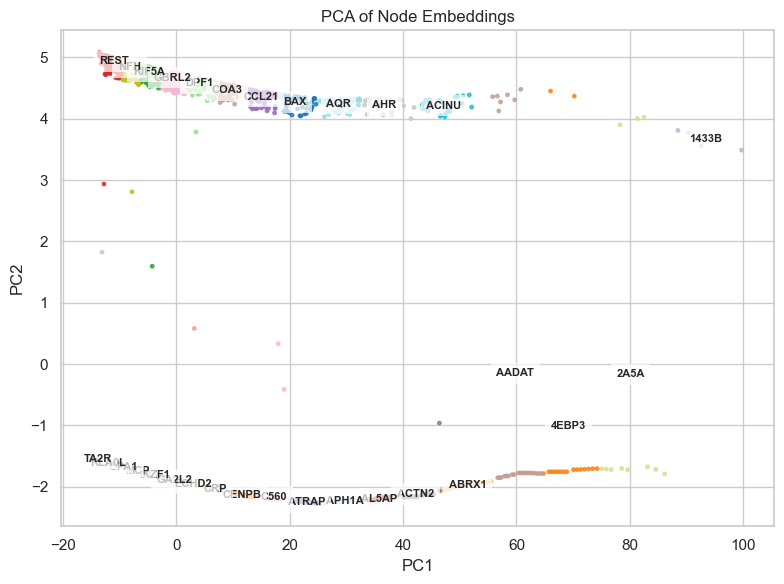

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(all_embeddings_initial)

plt.figure(figsize=(8, 6))
plt.scatter(
    embeddings_pca[:, 0],
    embeddings_pca[:, 1],
    c=cluster_labels_initial,
    cmap="tab20",
    s=6,
    alpha=0.8
)

annotate_cluster_centroids(
    embeddings_pca,
    cluster_labels_initial,
    first_node_stId_in_cluster_initial
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Node Embeddings")
plt.tight_layout()
plt.savefig(save_path_pca_initial, dpi=300)
plt.show()


/Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


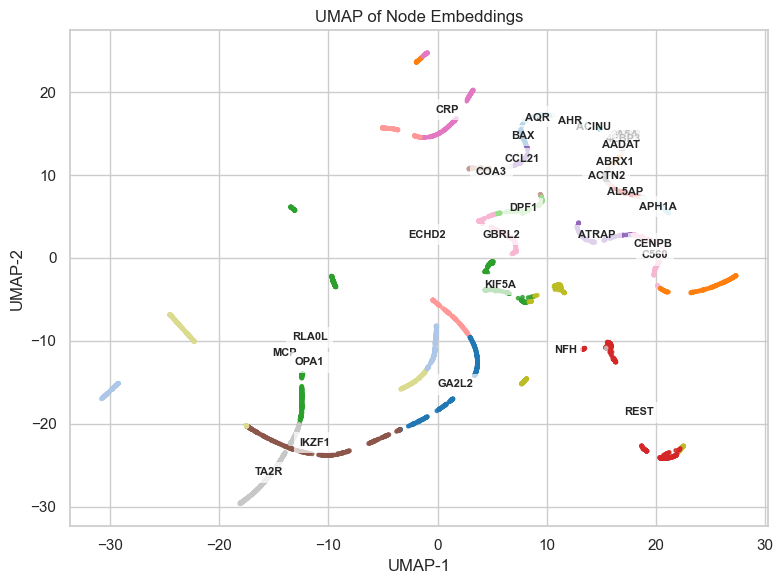

In [22]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embeddings_umap = umap_model.fit_transform(all_embeddings_initial)

plt.figure(figsize=(8, 6))
plt.scatter(
    embeddings_umap[:, 0],
    embeddings_umap[:, 1],
    c=cluster_labels_initial,
    cmap="tab20",
    s=6,
    alpha=0.8
)

annotate_cluster_centroids(
    embeddings_umap,
    cluster_labels_initial,
    first_node_stId_in_cluster_initial
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP of Node Embeddings")
plt.tight_layout()
plt.savefig(
    os.path.join(results_path, "ppi_embeddings_umap_initial.png"),
    dpi=300
)
plt.show()


In [14]:
all_embeddings_initial, cluster_labels_initial = calculate_cluster_labels(
    best_model, dl_train, device
)

all_embeddings_initial = all_embeddings_initial.reshape(
    all_embeddings_initial.shape[0], -1
)


In [15]:
first_node_stId_in_cluster_initial = {}
first_node_embedding_in_cluster_initial = {}

for data in dl_train:
    graph, _ = data
    node_embeddings_initial = (
        best_model.get_node_embeddings(graph)
        .detach().cpu().numpy()
    )

    nx_graph = pickle.load(
        open(os.path.join(data_path, "raw/emb_train.pkl"), "rb")
    )

    node_to_index = {n: i for i, n in enumerate(nx_graph.nodes)}

    for node, cluster in zip(nx_graph.nodes, cluster_labels_initial):
        if "stId" not in nx_graph.nodes[node]:
            continue

        if cluster not in first_node_stId_in_cluster_initial:
            first_node_stId_in_cluster_initial[cluster] = nx_graph.nodes[node]["stId"]
            first_node_embedding_in_cluster_initial[cluster] = \
                node_embeddings_initial[node_to_index[node]]

    break


In [16]:
stid_list = [
    first_node_stId_in_cluster_initial[c]
    for c in sorted(first_node_stId_in_cluster_initial)
]

embedding_list = [
    first_node_embedding_in_cluster_initial[c]
    for c in sorted(first_node_embedding_in_cluster_initial)
]

create_heatmap_with_stid(
    embedding_list,
    stid_list,
    save_path_heatmap_initial
)

plot_cosine_similarity_matrix_for_clusters_with_values(
    embedding_list,
    stid_list,
    save_path_matrix_initial
)


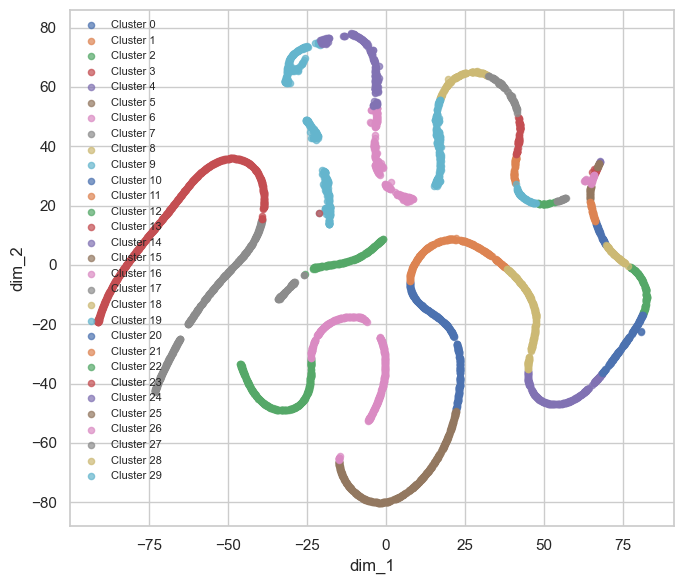

In [17]:
visualize_embeddings_tsne(
    all_embeddings_initial,
    cluster_labels_initial,
    stid_list=None,  # IMPORTANT
    save_path=save_path_t_SNE_initial
)


In [18]:
visualize_embeddings_pca(
    all_embeddings_initial,
    cluster_labels_initial,
    stid_list=None,
    save_path=save_path_pca_initial
)


TypeError: 'NoneType' object is not subscriptable

<Figure size 1000x1000 with 0 Axes>

In [13]:
print('first_node_stId_in_cluster_initial-------------------------------\n', first_node_stId_in_cluster_initial)
stid_list = list(first_node_stId_in_cluster_initial.values())
embedding_list_initial = list(first_node_embedding_in_cluster_initial.values())
create_heatmap_with_stid(embedding_list_initial, stid_list, save_path_heatmap_initial)
plot_cosine_similarity_matrix_for_clusters_with_values(embedding_list_initial, stid_list, save_path_matrix_initial)


all_embeddings_initial, cluster_labels_initial = calculate_cluster_labels(best_model, dl_train, device)
##print('all_embeddings_initial---------------------------------\n', all_embeddings_initial)
all_embeddings_initial = all_embeddings_initial.reshape(all_embeddings_initial.shape[0], -1)  # Flatten 
save_path_heatmap_initial= os.path.join(results_path, f'ppi_embeddings_heatmap_stId_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')
save_path_matrix_initial= os.path.join(results_path, f'ppi_embeddings_matrix_stId_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')
save_path_pca_initial = os.path.join(results_path, f'ppi_embeddings_pca_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')
save_path_t_SNE_initial = os.path.join(results_path, f'ppi_embeddings_t-SNE_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')

visualize_embeddings_tsne(all_embeddings_initial, cluster_labels_initial, stid_list, save_path_t_SNE_initial)
visualize_embeddings_pca(all_embeddings_initial, cluster_labels_initial, stid_list, save_path_pca_initial)   

NameError: name 'first_node_stId_in_cluster_initial' is not defined

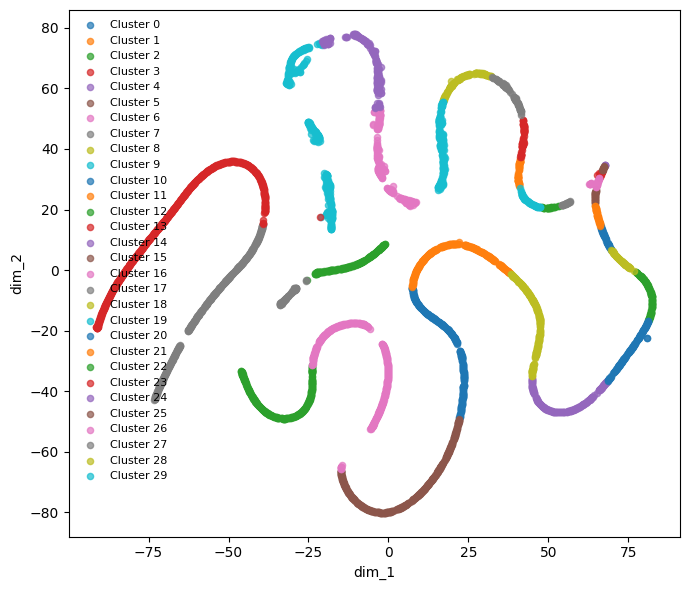

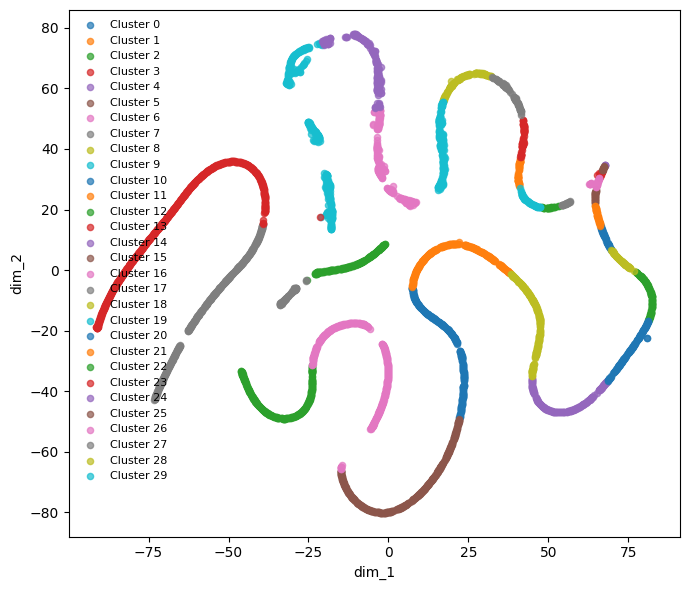

IndexError: list index out of range

<Figure size 1000x1000 with 0 Axes>

In [11]:
all_embeddings, cluster_labels = calculate_cluster_labels(
    best_model, dl_train, device
)
all_embeddings = all_embeddings.reshape(all_embeddings.shape[0], -1)

visualize_embeddings_tsne(
    all_embeddings,
    cluster_labels,
    stid_list=None,   # ← explicitly None
    save_path=os.path.join(results_path, "tsne_final.png")
)

# all_embeddings, cluster_labels, _ = calculate_cluster_labels(
#     best_model, dl_train, device
# )

visualize_embeddings_tsne(
    all_embeddings,
    cluster_labels,
    save_path=os.path.join(results_path, "tsne_final.png")
)
# visualize_embeddings_tsne(
#     all_embeddings,
#     cluster_labels,
#     stid_list=stid_list,
#     save_path=save_path_t_SNE
# )

# visualize_embeddings_tsne(
#     all_embeddings,
#     cluster_labels,
#     [],
#     os.path.join(results_path, "tsne_final.png")
# )

visualize_embeddings_pca(
    all_embeddings,
    cluster_labels,
    [],
    os.path.join(results_path, "pca_final.png")
)


In [ ]:
draw_loss_plot(
    loss_per_epoch_train,
    loss_per_epoch_valid,
    os.path.join(results_path, "loss.png")
)

draw_f1_plot(
    f1_per_epoch_train,
    f1_per_epoch_valid,
    os.path.join(results_path, "f1.png")
)


In [ ]:
torch.save(best_model.state_dict(), model_path)
print(f"Best model saved to {model_path}")


## Network definition

Usage example

We notice that R-HSA-1358803 corresponds to "Downregulation of ERBB2:ERBB3 signaling", and is significant in the network created with the markers specified above (its p-value is 0.0109 which is less than 0.05). On the other hand, R-HSA-15869 corresponds to "Metabolism of nucleotides" which is non-significant in this network (its p-value is 0.161).

Next we want to do is create an embedding of that graph. But in order to do that, graph should be in the DGL format.

We also need a GNN model which will produce the embeddings. Since we want the model to be reusable at any given time, the parameters of the model have to be saved to the disk and loaded upon model initialization. The demo model that is already saved is a 5-layers Graph Convolutional Network (GCN) and creates the the embeddings with latent dimension of 16.

The GCN is chosen because it is a relatively "lightweight" model that was proven to have good performance on various graph-related tasks. For example, even when comparing an untrained GCN network against DeepWalk on semi-supervised node classification task, untrained GCN had superior performance! This means that it can more successfully leverage the topology of a graph and create meaningful representation than the traditional methods.

First let's use a pretrained model which is saved as `data/example/models/model.pth`.

In [ ]:
# Imports
import os
import pickle
import torch
import dgl

import utils
import model

# -----------------------------
# Configuration (edit as needed)
# -----------------------------
data_dir = "data/emb"
output_file = "data/emb/embeddings.pkl"

p_value = 0.05          # currently unused (commented in utils call)
save = True
print_embeddings = False

num_epochs = 27
in_feats = 20
out_feats = 300
num_layers = 2
num_heads = 2
batch_size = 1
lr = 1e-3

device = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# Create embeddings with genes
# -----------------------------
# utils.create_embedding_with_genes(
#     # p_value=p_value,   # uncomment if needed
#     save=save,
#     data_dir=data_dir
# )

# -----------------------------
# Hyperparameters dictionary
# -----------------------------
hyperparameters = {
    "num_epochs": num_epochs,
    "in_feats": in_feats,
    "out_feats": out_feats,
    "num_layers": num_layers,
    "num_heads": num_heads,
    "batch_size": batch_size,
    "device": device,
    "lr": lr,
}

# -----------------------------
# Create embeddings
# -----------------------------
embedding_dict = utils.create_embeddings(
    data_dir=data_dir,
    load_model=False,
    hyperparams=hyperparameters
)

# -----------------------------
# Optional: print embeddings
# -----------------------------
if print_embeddings:
    print(embedding_dict)

# -----------------------------
# Save embeddings
# -----------------------------
os.makedirs(os.path.dirname(output_file), exist_ok=True)
with open(output_file, "wb") as f:
    pickle.dump(embedding_dict, f)

print(f"Embeddings saved to {output_file}")


python(21398) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


first_node_stId_in_cluster_initial-------------------------------
 {12: '1433B', 3: '2ABA', 16: 'A2MG', 29: 'AATM', 5: 'ABRX1', 21: 'ACON', 22: 'ACTN2', 28: 'AKT1', 10: 'AKT2', 25: 'APC4', 13: 'ARFG1', 1: 'ATPF2', 20: 'BBS1', 17: 'BRE1A', 11: 'CCL21', 18: 'CD59', 4: 'CO4A6', 19: 'COA3', 26: 'DDB2', 8: 'DPF1', 15: 'EXOSX', 23: 'GBG3', 0: 'H3C', 6: 'K2C4', 14: 'KR191', 24: 'MYO5C', 2: 'NEBU', 9: 'QCR2', 7: 'RAI14', 27: 'STIM1'}


python(21411) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Training:   4%|▎         | 1/27 [00:01<00:43,  1.65s/epoch]

Best F1 Validation Score: 0.5900360144057623
Epoch 1 - F1 Train: 0.0, F1 Valid: 0.5900360144057623


Training:   7%|▋         | 2/27 [00:03<00:39,  1.57s/epoch]

...

 50%|█████     | 1/2 [00:00<00:00,  1.44it/s]

Embedding for emb_test.dgl saved to /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ACGNN/embedding_omics_cpdb_ppi/data/emb/embeddings/emb_test.pth


100%|██████████| 2/2 [00:01<00:00,  1.35it/s]

Embedding for emb_train.dgl saved to /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ACGNN/embedding_omics_cpdb_ppi/data/emb/embeddings/emb_train.pth


Embeddings saved to data/emb/embeddings.pkl
